In [1]:
import os, sys
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

# import thetaflow as thf
import modelnn2 as thf

import json
import gc
import glob
from pathlib import Path

sys.path.append("../")
import gndr_utils as utils

I0000 00:00:1781003580.774173 1517586 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781003580.810973 1517586 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781003581.753157 1517586 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781003582.636026 1517586 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
metadata_train = pq.read_metadata('../Cross Validation Data/train_data_small.parquet')
metadata_test = pq.read_metadata('../Cross Validation Data/test_data_small.parquet')
# metadata_train = pq.read_metadata('../../train_data.parquet')
# metadata_test = pq.read_metadata('../../test_data.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_test = num_rows_test

print("{} features".format(n_features))
print("{} colunas - Treino".format(n_train))
print("{} colunas - Teste".format(n_test))

96 features
225000 colunas - Treino
75000 colunas - Teste


In [3]:
# Parquet file path
parquet_file_path_train = "../Cross Validation Data/train_data_small.parquet"
parquet_file_path_test = "../Cross Validation Data/test_data_small.parquet"
# parquet_file_path_train = "../../train_data.parquet"
# parquet_file_path_test = "../../test_data.parquet"

df_train = pd.read_parquet( parquet_file_path_train )
df_test = pd.read_parquet( parquet_file_path_test )

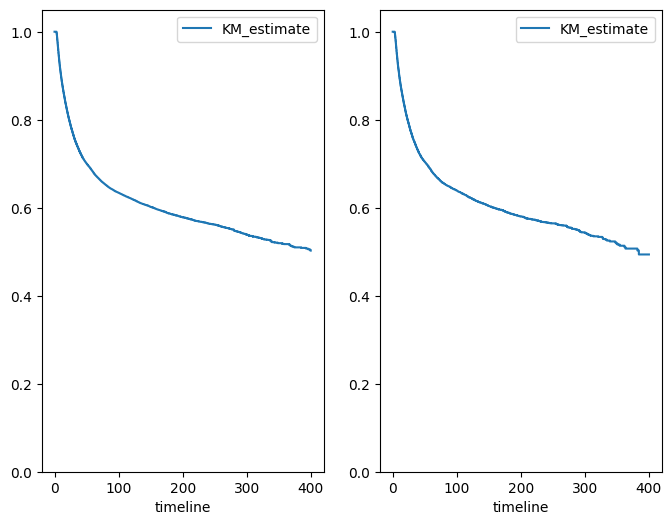

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

### Defining Accelerated Failure Time model structures

In [5]:
def get_AFT_model( X, dist = "weibull", theta_init = None, beta_init = None ):
    '''
        Given a design matrix for the variables we have the interest of interpreting and the desired proportional hazards
        distribution, we create the corresponding thetaflow native function definitions of that model, considering the
        vector of linear coefficients to be the exact same size as X.

        X: Design matrix for interpretable data
        dist: Name of the distribution user wants to fit: ["exponential", "weibull", "lognormal", "loglogistic", "bs"]
        theta_init: Vector of initial values for base distribution parameters. It expects a dict whose keys
                    correspond to the specific distribution chosen.
                    List of parameter names:
                        - exponential: scale
                        - weibull: shape, scale
                        - lognormal: mu, scale
                        - loglogistic: shape, scale
                        - bs (Birnbaum-Saunders): shape, scale
    '''
    dist = dist.lower()
    if(dist == "exponential"):
        nn_output_size = 1
        parameters = {
            "scale": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": X.shape[1], "init": beta_init, "warmup_time": 0}
        }
        
        def loglikelihood_loss(model, nn_output, data):
            X, z, y, delta = data
            eps = tf.constant(1.0e-07, dtype=tf.float32)
        
            scale = model.get_variable("scale", nn_output)
            beta = model.get_variable("beta")[:,None]
        
            # Linear predictor and acceleration in time
            r_z = tf.matmul(z, beta)
            t0 = y * tf.math.exp(-r_z)
        
            # Basal evaluation at t0
            log_h_base = -tf.math.log(scale + eps)
            log_S_base = -t0 / scale
    
            # Evaluation of h_AFT
            log_h_AFT = log_h_base - r_z
            
            loglik_terms = delta * log_h_AFT + log_S_base
            return -tf.reduce_mean(loglik_terms)
            # return -tf.reduce_sum(loglik_terms)
            
    elif(dist == "weibull"):
        nn_output_size = 2
        parameters = {
            "shape": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "scale": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": X.shape[1], "init": beta_init, "warmup_time": 0}
        }
    
        def loglikelihood_loss(model, nn_output, data):
            # Unpack your data tuple
            X, z, y, delta = data
            eps = tf.constant(1.0e-07, dtype = tf.float32)
            
            k = model.get_variable("shape", nn_output)
            lam = model.get_variable("scale", nn_output)
            beta = model.get_variable("beta")[:,None]
            
            # Linear predictor and acceleration in time
            r_z = tf.matmul(z, beta)
            t0 = y * tf.math.exp(-r_z)
        
            # Basal evaluation at t0
            log_h_base = tf.math.log(k) - k * tf.math.log(lam) + (k-1) * tf.math.log( t0 + eps )
            log_S_base = - (t0 / lam)**k
    
            # Evaluation of h_AFT
            log_h_AFT = log_h_base - r_z
            
            loglik_terms = delta * log_h_AFT + log_S_base
            return -tf.reduce_mean(loglik_terms)

    elif(dist == "lognormal"):
        nn_output_size = 2
        parameters = {
            "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "scale": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": X.shape[1], "init": beta_init, "warmup_time": 0}
        }
    
        def loglikelihood_loss(model, nn_output, data):
            # Unpack your data tuple
            X, z, y, delta = data
            eps = tf.constant(1.0e-07, dtype = tf.float32)
            
            mu = model.get_variable("mu", nn_output)
            scale = model.get_variable("scale", nn_output)
            beta = model.get_variable("beta")[:,None]

            # Linear predictor and acceleration in time
            r_z = tf.matmul(z, beta)
            t0 = y * tf.math.exp(-r_z)
            log_t0 = tf.math.log(t0 + eps)
            
            normal_dist = tfp.distributions.Normal(loc = mu, scale = scale)
            
            # Basal evaluation at t0
            # Y ~ Lognormal(mu, sigma) => X = log(Y) ~ N(mu, sigma²)
            # P(Y > y) = P(log(Y) > log(y)) = P(X > log(y)) = S_N( log(y) )
            log_S_base = normal_dist.log_survival_function( log_t0 )
            # P(Y <= y) = Phi( (log(y) - mu) / sigma ) 
            # Therefore, f_Y(y) = phi( (log(y) - mu)/sigma ) * (y sigma)^(-1) => f_Y(y) = f_X( log_y ) / y
            log_f_base = normal_dist.log_prob(log_t0) - log_t0
            log_h_base = log_f_base - log_S_base
            
            # Evaluation of h_AFT
            log_h_AFT = log_h_base - r_z
            
            loglik_terms = delta * log_h_AFT + log_S_base
            return -tf.reduce_mean(loglik_terms)
            
    elif(dist == "loglogistic"):
        nn_output_size = 2
        parameters = {
            "scale": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "shape": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": X.shape[1], "init": beta_init, "warmup_time": 0}
        }
    
        def loglikelihood_loss(model, nn_output, data):
            # Unpack your data tuple
            X, z, y, delta = data
            eps = tf.constant(1.0e-07, dtype = tf.float32)
            
            a = model.get_variable("scale", nn_output)
            b = model.get_variable("shape", nn_output)
            beta = model.get_variable("beta")[:,None]

            # Linear predictor and acceleration in time
            r_z = tf.matmul(z, beta)
            t0 = y * tf.math.exp(-r_z)
            log_t0 = tf.math.log(t0 + eps)
            
            log_b = tf.math.log(b)
            log_a = tf.math.log(a)

            log_terms = tf.math.softplus( b*( log_t0 - log_a ) )
            log_S_base = -log_terms
            log_h_base = log_b - b * log_a + (b-1) * log_t0 - log_terms
            
            # Evaluation of h_AFT
            log_h_AFT = log_h_base - r_z
            
            loglik_terms = delta * log_h_AFT + log_S_base
            return -tf.reduce_mean(loglik_terms)
            
    elif( dist == "bs" ):
        nn_output_size = 2
        parameters = {
            "scale": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "shape": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": X.shape[1], "init": beta_init, "warmup_time": 0}
        }
    
        def loglikelihood_loss(model, nn_output, data):
            # Unpack your data tuple
            X, z, y, delta = data
            eps = tf.constant(1.0e-07, dtype = tf.float32)
            
            a = model.get_variable("shape", nn_output)
            b = model.get_variable("scale", nn_output)
            beta = model.get_variable("beta")[:,None]

            # Linear predictor and acceleration in time
            r_z = tf.matmul(z, beta)
            t0 = y * tf.math.exp(-r_z)
            log_t0 = tf.math.log(t0 + eps)
            
            pi = tf.constant( 3.141592653589793, dtype = tf.float32 )
            log_b = tf.math.log(b)
            log_a = tf.math.log(a)

            sqrt_b_t0 = tf.math.sqrt( b / (t0+eps) )
            sqrt_t0_b = tf.math.sqrt( t0 / b )
            normal_dist = tfp.distributions.Normal(loc = 0.0, scale = 1.0)
            z_score = (sqrt_t0_b - sqrt_b_t0) / a
            log_S_base = normal_dist.log_survival_function(z_score)
            log_f_base = -tf.math.log(2*tf.math.sqrt(2 * pi)) - log_a - log_b + \
                          tf.math.log( sqrt_b_t0 + tf.math.pow(sqrt_b_t0, 3) ) - (t0 / b + b / (t0 + eps) - 2) / (2*a**2)
            log_h_base = log_f_base - log_S_base
            
            # Evaluation of h_AFT
            log_h_AFT = log_h_base - r_z
            
            loglik_terms = delta * log_h_AFT + log_S_base
            return -tf.reduce_mean(loglik_terms)

    # Cycle through all parameters and set the initial value corresponding to a zero unconstrained value
    for par_name in parameters:
        if(par_name != "beta"):
            # If initial theta was not given, consider the initial value to be zero on the unconstrained scale
            if(theta_init is None or par_name not in theta_init):
                parameters[par_name]["init"] = parameters[par_name]["link"]( 0.0 )
            # Otherwise, just set the given values to each parameter
            else:
                parameters[par_name]["init"] = theta_init[par_name]

    # If beta init was not given, simply set all coefficients to zeros
    if(beta_init is None):
        parameters["beta"]["init"] = np.repeat(0.0, X.shape[1])

    return parameters, loglikelihood_loss, nn_output_size

In [6]:
def build_AFT_model( Z, dist  = "weibull", theta_init = None, beta_init = None ):

    parameters, loglikelihood_loss, nn_output_size = get_AFT_model( Z, dist = dist, theta_init = theta_init, beta_init = beta_init )
    
    def neural_network(model, seed = None):
        initializer = tf.keras.initializers.HeNormal(seed = seed)

        model.dense1 = layers.Dense(
            units = 128, 
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense2 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense3 = layers.Dense(
            units = 32,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense4 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.output_layer = layers.Dense(
            units = nn_output_size,
            activation = None, # Linear, o exponente fica na Loss function
            use_bias = True,
            kernel_initializer = tf.keras.initializers.Zeros()
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        return x

    return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

### Splitting data into linear components and neural network inputs

In [7]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

In [8]:
linear_columns = [0, 3, 4, 5, 6, 7, 8, 9, 10, 11]
neuralnet_columns = [i for i in np.arange(X_train.shape[1]) if i not in linear_columns]

z_train = X_train.iloc[:, linear_columns]
# z_train.insert(0, "intercept", 1.0)
X_train_nn = X_train.iloc[:, neuralnet_columns]
# Projection weights matrix from z to X
# W_train_nn = np.linalg.inv( z_train.T @ z_train ) @ z_train.T @ X_train_nn

# By using @, the pandas environment breaks, since z_train and W_train_nn do not share colum names
# z_proj_X_train = np.dot(z_train, W_train_nn)

# Remove the projection of z_train from the matrix to be fed to the neural network
# X_train_nn = X_train_nn - z_proj_X_train

z_test = X_test.iloc[:, linear_columns]
# z_test.insert(0, "intercept", 1.0)
X_test_nn = X_test.iloc[:, neuralnet_columns]
# Projection weights matrix from z to X
# W_test_nn = np.linalg.inv( z_test.T @ z_test ) @ z_test.T @ X_test_nn
# z_proj_X_test = np.dot(z_test, W_test_nn)
# X_test_nn = X_test_nn - z_proj_X_test

data_train = [z_train, y_train, delta_train]
data_test = [z_test, y_test, delta_test]

display( z_train.head(3) )
display( X_train_nn.head(3) )

,idade,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,faixa_remuneracao_media_até 1 SM,faixa_remuneracao_media_mais de 7 SM
0,-1.283593,0,0,0,1,0,0,0,0,0
1,-0.582427,0,0,0,0,0,0,0,0,0
2,-0.757718,0,0,0,0,0,1,0,0,0


,horas_semanais,qtd_dias_afastamento,escolaridade_5 ano completo,escolaridade_6 a 9 ano incompleto,escolaridade_analfabeto,escolaridade_ate 5 ano incompleto,escolaridade_doutorado,escolaridade_fundamental completo,escolaridade_medio incompleto,escolaridade_mestrado,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [9]:
# Exponential
exp_parameters, exp_loss, exp_neural_network, exp_call, exp_call_nolast = build_AFT_model( z_train, dist  = "exponential", theta_init = {"scale": 15.443197}, beta_init = None )
# Weibull
weibull_parameters, weibull_loss, weibull_neural_network, weibull_call, weibull_call_nolast = build_AFT_model( z_train, dist  = "weibull", theta_init = None, beta_init = None )
# Log-normal
lognormal_parameters, lognormal_loss, lognormal_neural_network, lognormal_call, lognormal_call_nolast = build_AFT_model( z_train, dist  = "lognormal", theta_init = None, beta_init = None )
# Log-logistic
loglogistic_parameters, loglogistic_loss, loglogistic_neural_network, loglogistic_call, loglogistic_call_nolast = build_AFT_model( z_train, dist  = "loglogistic", theta_init = None, beta_init = None )
# Birnbaun-Saunders
bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = build_AFT_model( z_train, dist  = "bs", theta_init = None, beta_init = None )

### Exponential model

In [33]:
with tf.device("/GPU:0"):
    seed = 10
    exp_model = thf.ModelNN(exp_parameters, exp_loss, exp_neural_network, exp_call, exp_call_nolast,
                            input_dim = (X_train_nn.shape[1],), seed = seed)
    exp_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    exp_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                          shuffle = True,
                          get_covariances = True,
                          validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                          force_training_validation = False,
                          optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                          optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                          fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                          early_stopping = True, early_stopping_patience = 10, 
                          early_stopping_warmup = 50,
                          reduce_lr = True, reduce_lr_warmup = 0,
                          reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                          # reduce_lr_factor = 0.5, reduce_lr_min_delta = 2.0, reduce_lr_patience = 5,
                          reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                          fine_tune = True,
                          finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                          finetune_early_stopping_warmup = 50,
                          finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                          finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                          # finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0, finetune_reduce_lr_patience = 5,
                          finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                          deterministic = True,
                          verbose = True, print_freq = 1,
                          train_batch_size = None, val_batch_size = None,
                          buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 162 / 5000 ]  | Loss:  0.786839247 | Best Loss:  0.787782788 | Speed:  28  epoch/s    | Elapsed Time:  5.69286585  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 147 / 5000 ]  | Loss:  0.746609747 | Best Loss:  0.746685565 | Speed:  47  epoch/s    | Elapsed Time:  3.06350684  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 12.169 seconds.


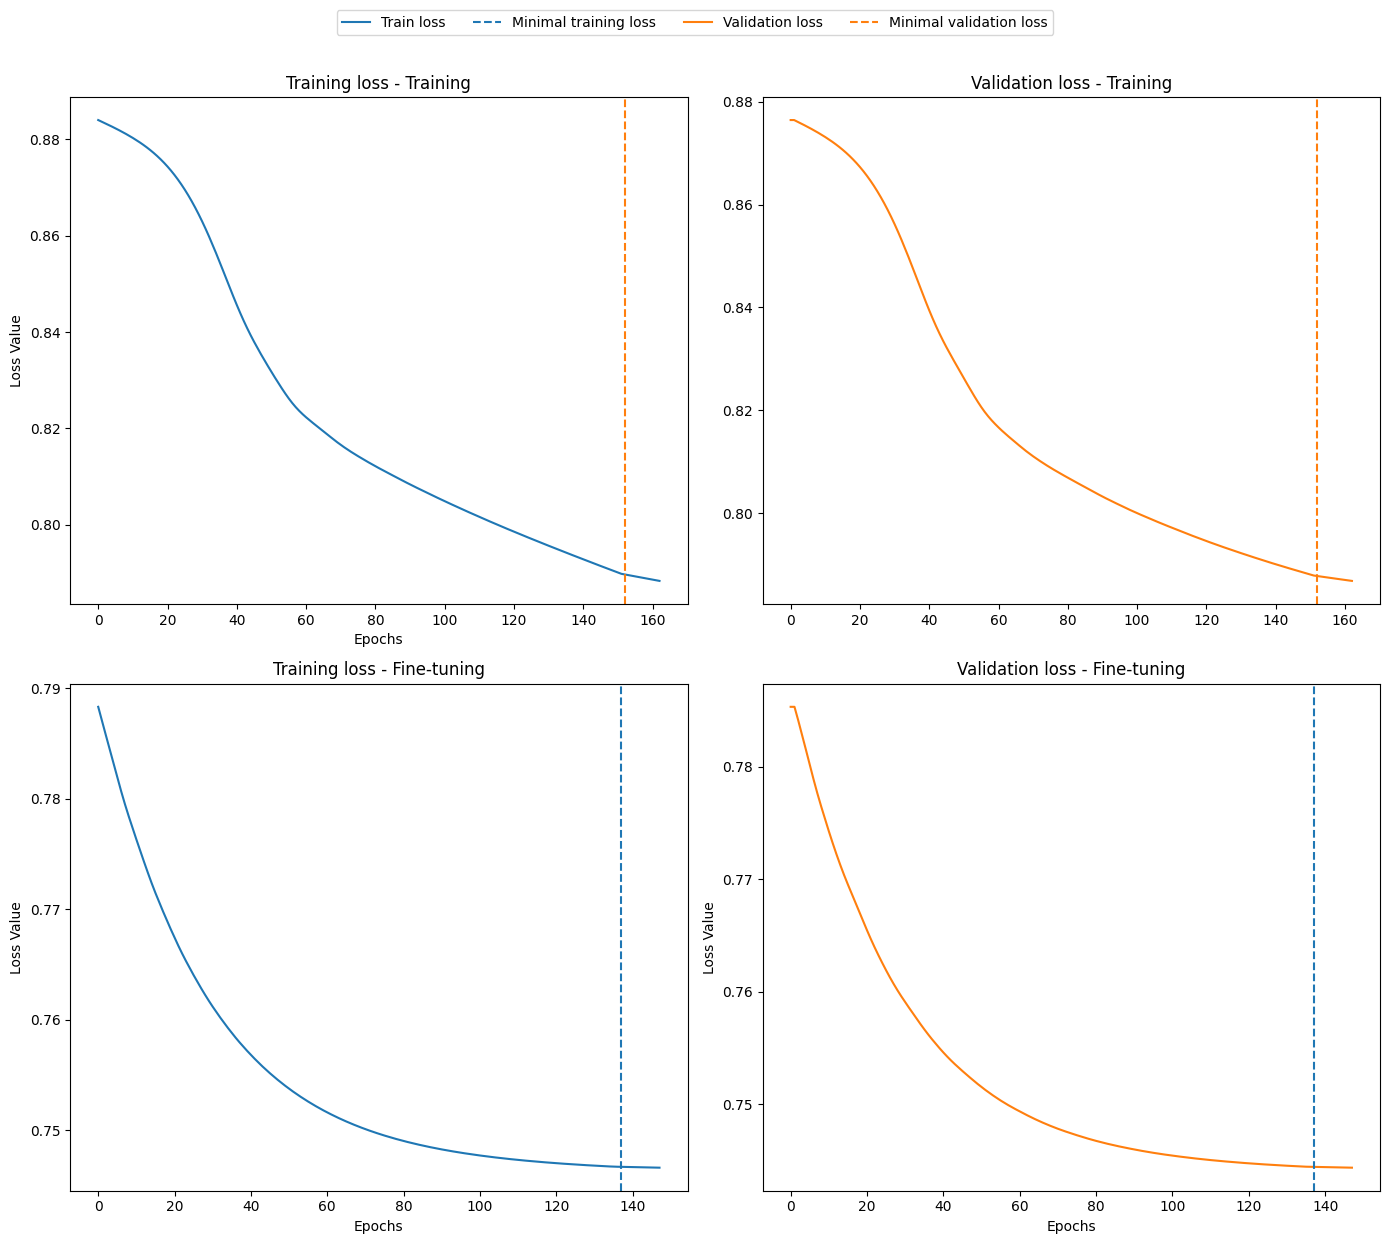

In [34]:
utils.plot_model_convergence( exp_model )

In [72]:
def get_survival_exp(model, y_train, z_train, X_train, y_test, z_test, X_test, ngrid = 100):
    scale_train = model.predict(X_train)["scale"].numpy().flatten()
    scale_test = model.predict(X_test)["scale"].numpy().flatten()
    beta = model.predict("beta")[:,None]
    
    ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), ngrid)[:,None]

    r_z_train = np.dot(z_train, beta).flatten()
    t0_grid_train = ts_grid * np.exp( -r_z_train )
    S_ts_train = np.exp( - t0_grid_train / scale_train )
    t0_train = y_train * np.exp( -r_z_train )
    S_train = np.exp( - t0_train / scale_train )
    H_train = -np.log( S_train )

    r_z_test = np.dot(z_test, beta).flatten()
    t0_grid_test = ts_grid * np.exp( -r_z_test )
    S_ts_test = np.exp( -t0_grid_test / scale_test )
    t0_test = y_test * np.exp( -r_z_test )
    S_test = np.exp( - t0_test / scale_test )
    H_test = -np.log( S_test )

    return {
        "ts_grid": ts_grid,
        "S_ts_train": S_ts_train,
        "S_ts_test": S_ts_test,
        "S_train": S_train,
        "S_test": S_test,
        "H_train": H_train,
        "H_test": H_test
    }

(100, 1)
(225000,)


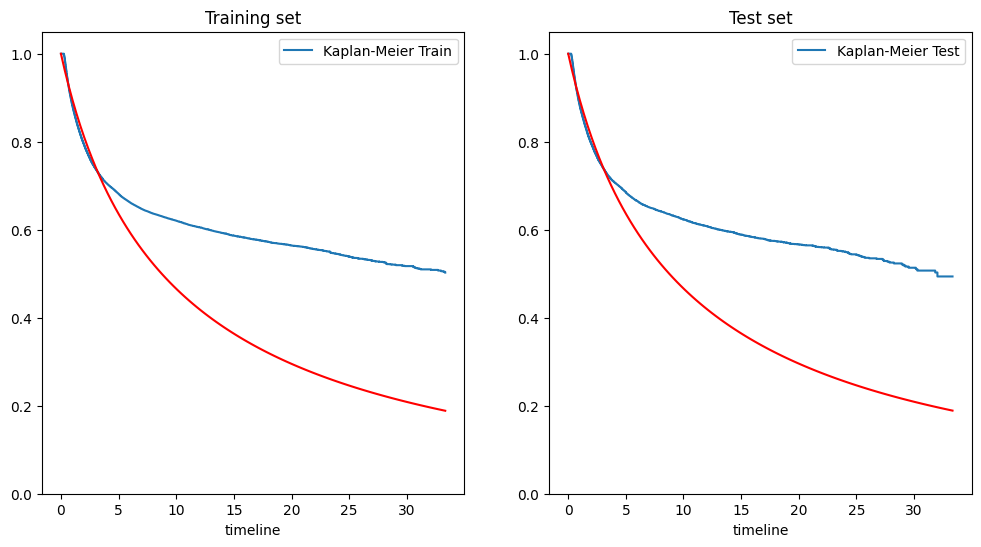

In [71]:
results_exp = get_survival_exp(exp_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_exp["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_exp["S_ts_train"].shape[1]), size = np.min([n_max, results_exp["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_exp["S_ts_test"].shape[1]), size = np.min([n_max, results_exp["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_exp["ts_grid"].flatten(),
                           results_exp["S_ts_train"][:, train_idx], results_exp["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [37]:
beta_summary = exp_model.summary()

beta_hats = []
beta_ses = []
beta_statistics = []
beta_pvalues = []
beta_CIs = []
for j, beta in enumerate(beta_summary.columns[1::4]):
    beta_hat = float( beta_summary.iloc[0,j*4+1] )
    se = float( beta_summary.iloc[0,j*4+2] )

    test_statistic = beta_hat / se
    p_value = 2.0 * (1.0 - norm.cdf(np.abs(test_statistic)))
    
    lower = float( beta_summary.iloc[0,j*4+3] )
    upper = float( beta_summary.iloc[0,j*4+4] )

    beta_hats.append( beta_hat )
    beta_ses.append( se )
    beta_statistics.append( test_statistic )
    beta_pvalues.append( p_value )
    beta_CIs.append("({} ; {})".format(np.round(lower,4), np.round(upper,4)))
beta_summary = pd.DataFrame({"Coef": beta_hats, "Se": beta_ses, "Z": beta_statistics, "pvalue": beta_pvalues, "CI(95%)": beta_CIs})
beta_summary.index = z_train.columns
beta_summary

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2719: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,0.546257,0.005449,100.248694,0.000000,(0.5356 ; 0.5569)
sexo_feminino,-0.014541,0.010331,-1.407520,0.159273,(-0.0348 ; 0.0057)
raca_amarela,-0.118373,0.045504,-2.601386,0.009285,(-0.2076 ; -0.0292)
raca_indigena,-0.076954,0.091150,-0.844251,0.398529,(-0.2556 ; 0.1017)
raca_parda,-0.023908,0.010756,-2.222674,0.026238,(-0.045 ; -0.0028)
raca_preta,-0.087960,0.018334,-4.797790,0.000002,(-0.1239 ; -0.052)
faixa_remuneracao_media_2 a 4 SM,0.522336,0.015564,33.561326,0.000000,(0.4918 ; 0.5528)
faixa_remuneracao_media_4 a 7 SM,0.618291,0.026636,23.212981,0.000000,(0.5661 ; 0.6705)
faixa_remuneracao_media_até 1 SM,-0.774837,0.011515,-67.286531,0.000000,(-0.7974 ; -0.7523)
faixa_remuneracao_media_mais de 7 SM,0.674648,0.031222,21.608260,0.000000,(0.6135 ; 0.7358)


### Weibull model

In [38]:
with tf.device("/GPU:0"):
    seed = 10
    weibull_model = thf.ModelNN(weibull_parameters, weibull_loss, weibull_neural_network, weibull_call, weibull_call_nolast,
                                input_dim = (X_train_nn.shape[1],), seed = seed)
    weibull_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    weibull_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                              force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                              optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 10, 
                              early_stopping_warmup = 50,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                              # reduce_lr_factor = 0.5, reduce_lr_min_delta = 2.0, reduce_lr_patience = 5,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                              finetune_early_stopping_warmup = 50,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                              # finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0, finetune_reduce_lr_patience = 5,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1,
                              train_batch_size = None, val_batch_size = None,
                              buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 100 / 5000 ]  | Loss:  0.856705725 | Best Loss:  0.850209177 | Speed:  25  epoch/s    | Elapsed Time:  3.86323166  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 786 / 5000 ]  | Loss:  0.778509557 | Best Loss:  0.778607666 | Speed:  43  epoch/s    | Elapsed Time:  17.9205437  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 25.389 seconds.


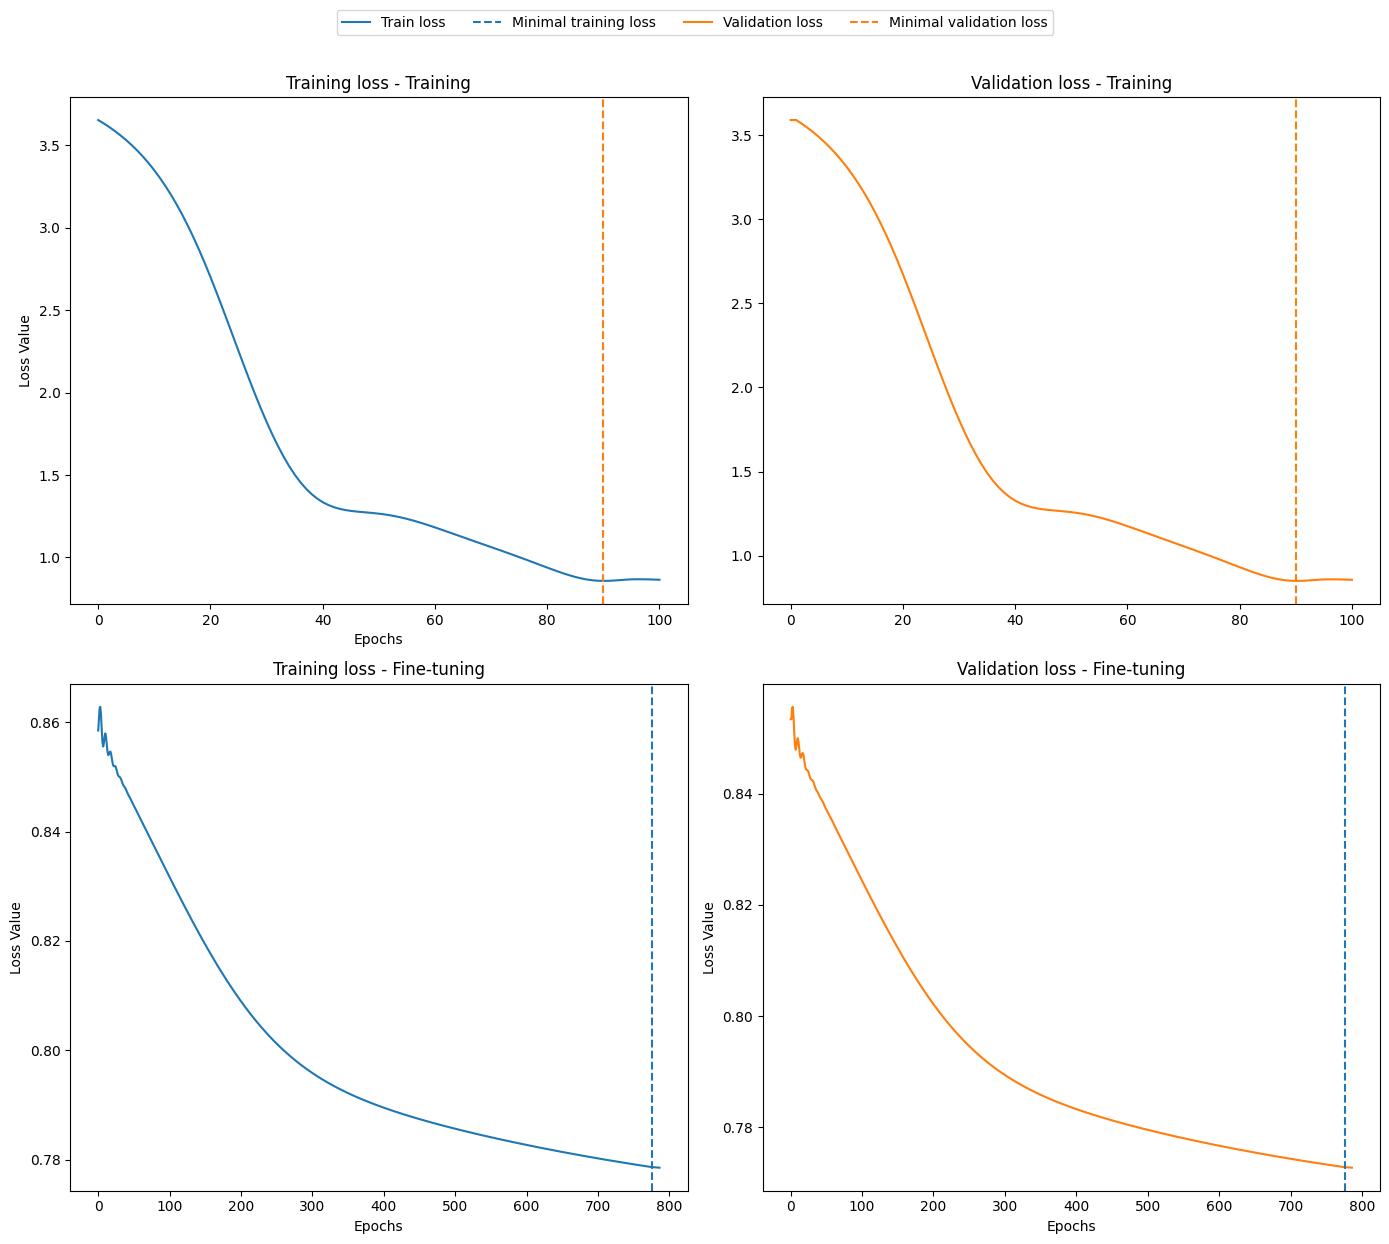

In [39]:
utils.plot_model_convergence( weibull_model )

In [ ]:
def get_survival_exp(model, y_train, z_train, X_train, y_test, z_test, X_test, ngrid = 100):
    scale_train = model.predict(X_train)["scale"].numpy().flatten()
    scale_test = model.predict(X_test)["scale"].numpy().flatten()
    beta = model.predict("beta")[:,None]
    
    ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), ngrid)[:,None]

    r_z_train = np.dot(z_train, beta).flatten()
    t0_grid_train = ts_grid * np.exp( -r_z_train )
    S_ts_train = np.exp( - t0_grid_train / scale_train )
    t0_train = y_train * np.exp( -r_z_train )
    S_train = np.exp( - t0_train / scale_train )
    H_train = -np.log( S_train )

    r_z_test = np.dot(z_test, beta).flatten()
    t0_grid_test = ts_grid * np.exp( -r_z_test )
    S_ts_test = np.exp( -t0_grid_test / scale_test )
    t0_test = y_test * np.exp( -r_z_test )
    S_test = np.exp( - t0_test / scale_test )
    H_test = -np.log( S_test )

    return {
        "ts_grid": ts_grid,
        "S_ts_train": S_ts_train,
        "S_ts_test": S_ts_test,
        "S_train": S_train,
        "S_test": S_test,
        "H_train": H_train,
        "H_test": H_test
    }

In [77]:
def get_survival_weibull(model, y_train, z_train, X_train, y_test, z_test, X_test, ngrid = 100):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    k_train = pred_train["shape"].numpy().flatten()
    lam_train = pred_train["scale"].numpy().flatten()
    k_test = pred_test["shape"].numpy().flatten()
    lam_test = pred_test["scale"].numpy().flatten()
    beta = model.predict("beta")[:,None]

    ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), ngrid)[:,None]
    
    r_z_train = np.dot(z_train, beta).flatten()
    t0_grid_train = ts_grid * np.exp( -r_z_train )
    S_ts_train = np.exp( - (t0_grid_train / lam_train)**k_train )
    t0_train = y_train * np.exp( -r_z_train )
    S_train = np.exp( - (t0_train / lam_train)**k_train )
    H_train = -np.log( S_train )
    
    r_z_test = np.dot(z_test, beta).flatten()
    t0_grid_test = ts_grid * np.exp( -r_z_test )
    S_ts_test = np.exp( - (t0_grid_test / lam_test)**k_test )
    t0_test = y_test * np.exp( -r_z_test )
    S_test = np.exp( - (t0_test / lam_test)**k_test )
    H_test = -np.log( S_test )
    
    S0_ts_test = np.exp( -(ts_grid / lam_test)**k_test )
    S_ts_test = S0_ts_test**np.exp( np.dot( z_test, beta ).T )
    S_test = np.exp( - y_test / lam_test )
    H_test = -np.log( S_test )

    return {
        "ts_grid": ts_grid,
        "S_ts_train": S_ts_train,
        "S_ts_test": S_ts_test,
        "S_train": S_train,
        "S_test": S_test,
        "H_train": H_train,
        "H_test": H_test
    }

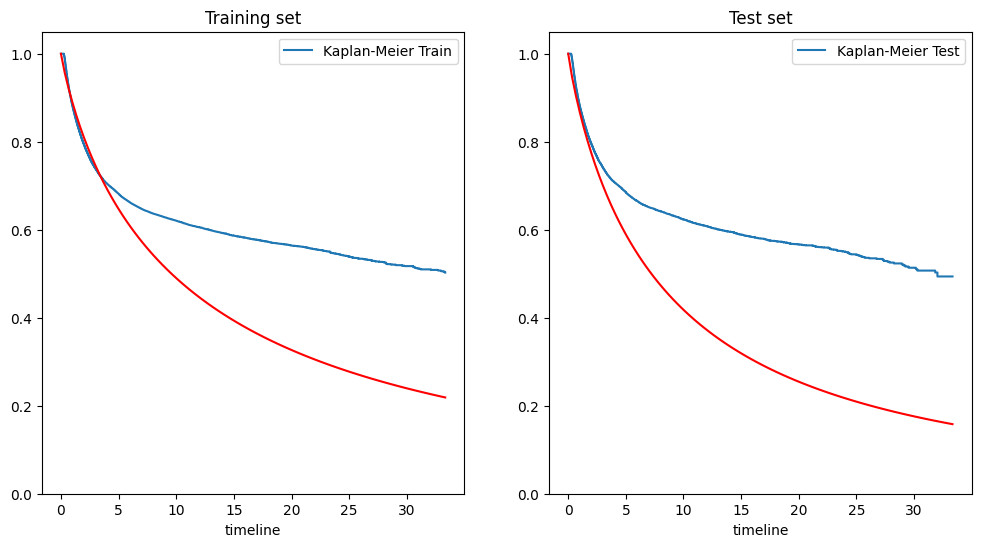

In [78]:
results_weibull = get_survival_weibull(weibull_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_weibull["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_weibull["S_ts_train"].shape[1]), size = np.min([n_max, results_weibull["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_weibull["S_ts_test"].shape[1]), size = np.min([n_max, results_weibull["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_weibull["ts_grid"].flatten(),
                           results_weibull["S_ts_train"][:, train_idx], results_weibull["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [79]:
beta_summary = weibull_model.summary()

beta_hats = []
beta_ses = []
beta_statistics = []
beta_pvalues = []
beta_CIs = []
for j, beta in enumerate(beta_summary.columns[1::4]):
    beta_hat = float( beta_summary.iloc[0,j*4+1] )
    se = float( beta_summary.iloc[0,j*4+2] )

    test_statistic = beta_hat / se
    p_value = 2.0 * (1.0 - norm.cdf(np.abs(test_statistic)))
    
    lower = float( beta_summary.iloc[0,j*4+3] )
    upper = float( beta_summary.iloc[0,j*4+4] )

    beta_hats.append( beta_hat )
    beta_ses.append( se )
    beta_statistics.append( test_statistic )
    beta_pvalues.append( p_value )
    beta_CIs.append("({} ; {})".format(np.round(lower,4), np.round(upper,4)))
beta_summary = pd.DataFrame({"Coef": beta_hats, "Se": beta_ses, "Z": beta_statistics, "pvalue": beta_pvalues, "CI(95%)": beta_CIs})
beta_summary.index = z_train.columns
beta_summary

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2719: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,0.588319,0.005689,103.412294,0.000000,(0.5772 ; 0.5995)
sexo_feminino,0.155554,0.010771,14.441707,0.000000,(0.1344 ; 0.1767)
raca_amarela,0.062567,0.049284,1.269507,0.204260,(-0.034 ; 0.1592)
raca_indigena,0.072198,0.098882,0.730143,0.465303,(-0.1216 ; 0.266)
raca_parda,0.133042,0.011361,11.709944,0.000000,(0.1108 ; 0.1553)
raca_preta,0.088642,0.019587,4.525517,0.000006,(0.0503 ; 0.127)
faixa_remuneracao_media_2 a 4 SM,0.483835,0.016417,29.470817,0.000000,(0.4517 ; 0.516)
faixa_remuneracao_media_4 a 7 SM,0.618665,0.027183,22.759143,0.000000,(0.5654 ; 0.6719)
faixa_remuneracao_media_até 1 SM,-0.987846,0.012556,-78.677000,0.000000,(-1.0125 ; -0.9632)
faixa_remuneracao_media_mais de 7 SM,0.719144,0.031281,22.990027,0.000000,(0.6578 ; 0.7805)


### Log-normal model

In [82]:
with tf.device("/GPU:0"):
    seed = 10
    lognormal_model = thf.ModelNN(lognormal_parameters, lognormal_loss, lognormal_neural_network, lognormal_call, lognormal_call_nolast,
                                  input_dim = (X_train_nn.shape[1],), seed = seed)
    lognormal_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    lognormal_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                                shuffle = True,
                                get_covariances = True,
                                validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                force_training_validation = False,
                                optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                early_stopping = True, early_stopping_patience = 10, 
                                early_stopping_warmup = 50,
                                reduce_lr = True, reduce_lr_warmup = 0,
                                reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                                reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                fine_tune = True,
                                finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                finetune_early_stopping_warmup = 50,
                                finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                                finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                deterministic = True,
                                verbose = True, print_freq = 1,
                                train_batch_size = None, val_batch_size = None,
                                buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 78 / 5000 ]  | Loss:  0.817332268 | Best Loss:  0.81663388 | Speed:  22  epoch/s    | Elapsed Time:  3.47467637  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 421 / 5000 ]  | Loss:  0.758308589 | Best Loss:  0.758406222 | Speed:  39  epoch/s    | Elapsed Time:  10.5930243  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 19.208 seconds.


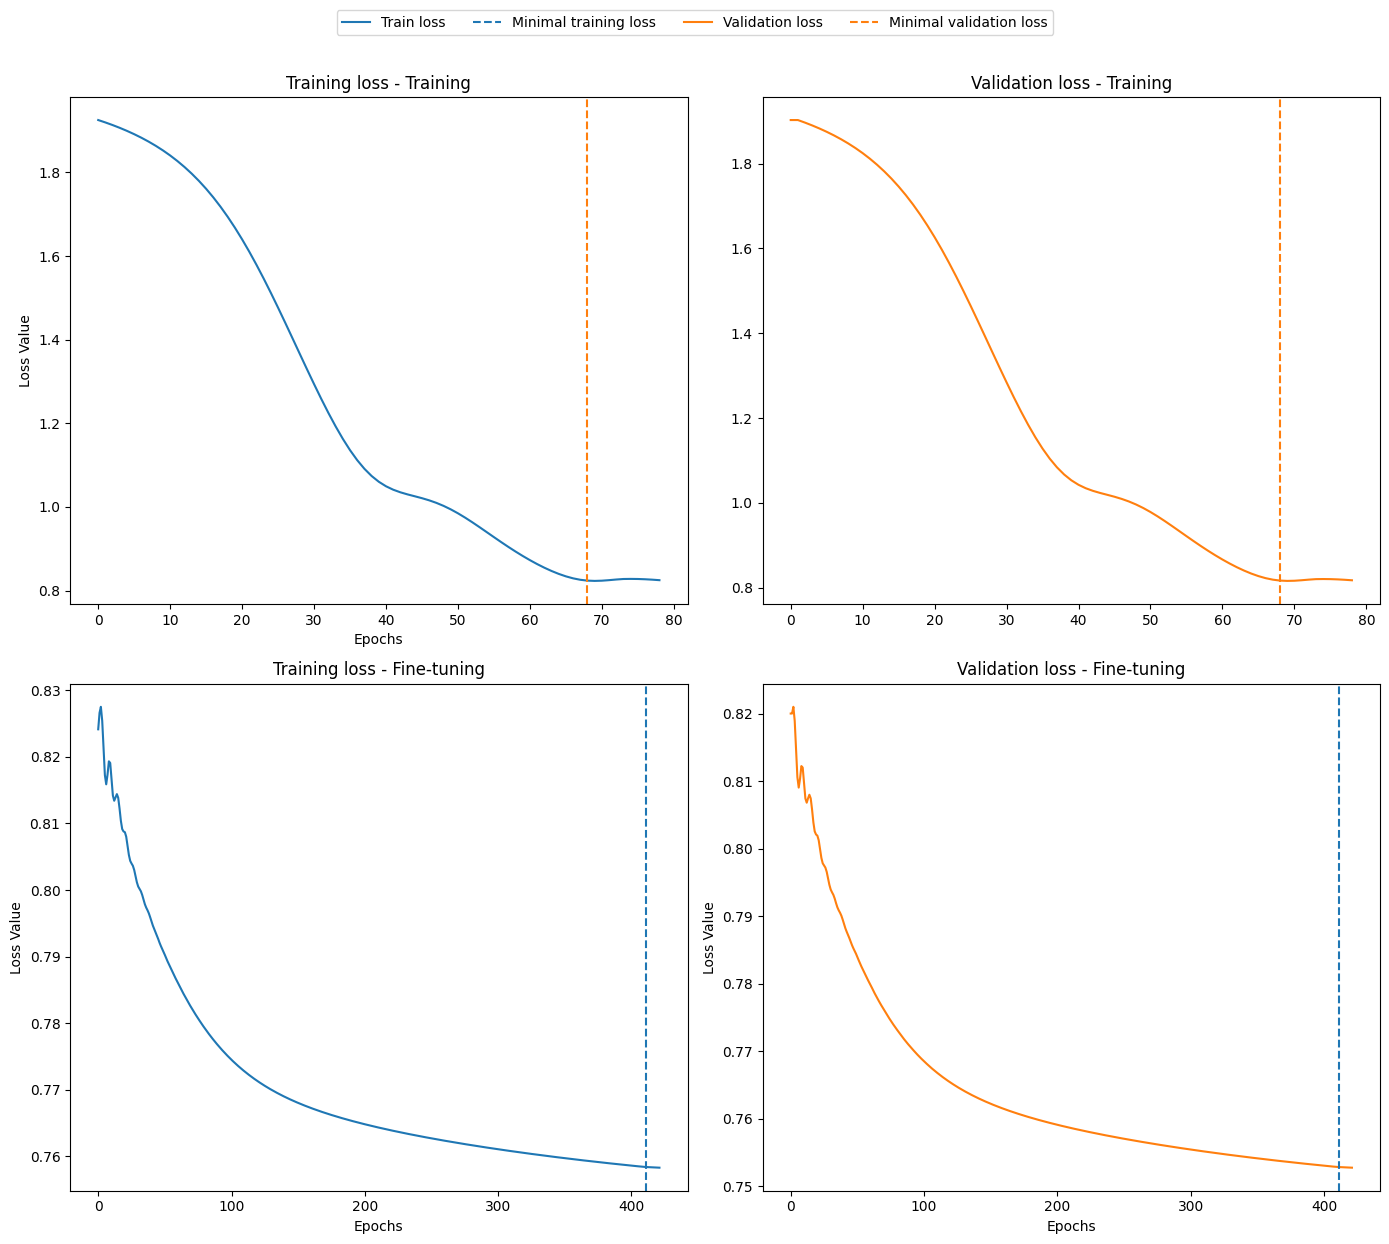

In [83]:
utils.plot_model_convergence( lognormal_model )

In [90]:
def get_survival_lognormal(model, y_train, z_train, X_train, y_test, z_test, X_test, ngrid = 100):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    mu_train = pred_train["mu"].numpy().flatten()
    sigma_train = pred_train["scale"].numpy().flatten()
    mu_test = pred_test["mu"].numpy().flatten()
    sigma_test = pred_test["scale"].numpy().flatten()
    beta = model.predict("beta")[:,None]

    ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), ngrid)[:,None]
    
    r_z_train = np.dot(z_train, beta).flatten()
    t0_grid_train = ts_grid * np.exp( -r_z_train )
    log_t0_grid_train = np.log( t0_grid_train )
    
    normal_dist_train = tfp.distributions.Normal(loc = mu_train, scale = sigma_train)
    S_ts_train = normal_dist_train.survival_function( log_t0_grid_train ).numpy()
    t0_train = y_train * np.exp( -r_z_train )
    log_t0_train = np.log(t0_train)
    S_train = normal_dist_train.survival_function( log_t0_train ).numpy()
    H_train = -np.log( S_train )

    r_z_test = np.dot(z_test, beta).flatten()
    t0_grid_test = ts_grid * np.exp( -r_z_test )
    log_t0_grid_test = np.log( t0_grid_test )
    
    normal_dist_test = tfp.distributions.Normal(loc = mu_test, scale = sigma_test)
    S_ts_test = normal_dist_test.survival_function( log_t0_grid_test ).numpy()
    t0_test = y_test * np.exp( -r_z_test )
    log_t0_test = np.log(t0_test)
    S_test = normal_dist_test.survival_function( log_t0_test ).numpy()
    H_test = -np.log( S_test )
    
    return {
        "ts_grid": ts_grid,
        "S_ts_train": S_ts_train,
        "S_ts_test": S_ts_test,
        "S_train": S_train,
        "S_test": S_test,
        "H_train": H_train,
        "H_test": H_test
    }

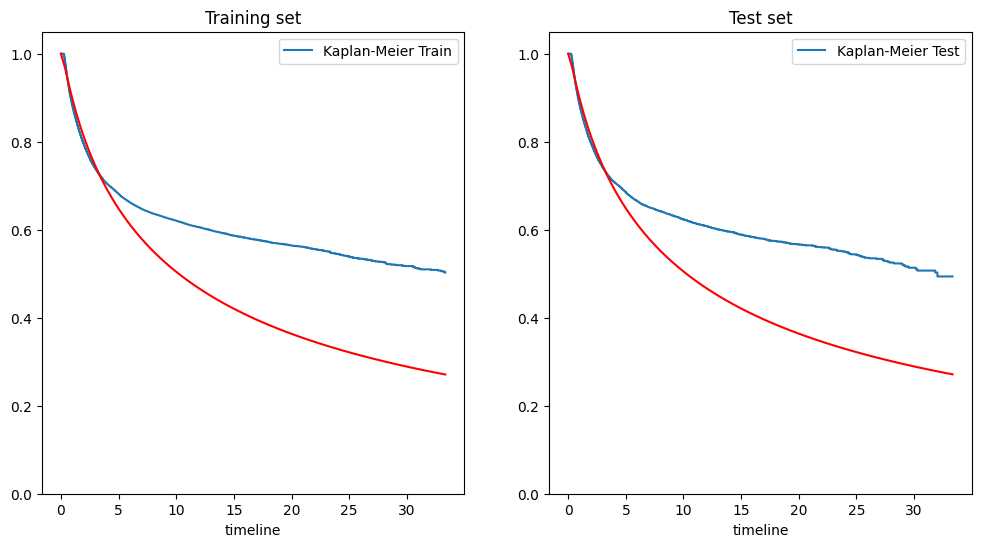

In [102]:
results_lognormal = get_survival_lognormal(lognormal_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_lognormal["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_lognormal["S_ts_train"].shape[1]), size = np.min([n_max, results_lognormal["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_lognormal["S_ts_test"].shape[1]), size = np.min([n_max, results_lognormal["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_lognormal["ts_grid"].flatten(),
                           results_lognormal["S_ts_train"][:, train_idx], results_lognormal["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [104]:
beta_summary = lognormal_model.summary()

beta_hats = []
beta_ses = []
beta_statistics = []
beta_pvalues = []
beta_CIs = []
for j, beta in enumerate(beta_summary.columns[1::4]):
    beta_hat = float( beta_summary.iloc[0,j*4+1] )
    se = float( beta_summary.iloc[0,j*4+2] )

    test_statistic = beta_hat / se
    p_value = 2.0 * (1.0 - norm.cdf(np.abs(test_statistic)))
    
    lower = float( beta_summary.iloc[0,j*4+3] )
    upper = float( beta_summary.iloc[0,j*4+4] )

    beta_hats.append( beta_hat )
    beta_ses.append( se )
    beta_statistics.append( test_statistic )
    beta_pvalues.append( p_value )
    beta_CIs.append("({} ; {})".format(np.round(lower,4), np.round(upper,4)))
beta_summary = pd.DataFrame({"Coef": beta_hats, "Se": beta_ses, "Z": beta_statistics, "pvalue": beta_pvalues, "CI(95%)": beta_CIs})
beta_summary.index = z_train.columns
beta_summary

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2719: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,0.490915,0.005441,90.219024,0.000000e+00,(0.4802 ; 0.5016)
sexo_feminino,0.127549,0.010825,11.782653,0.000000e+00,(0.1063 ; 0.1488)
raca_amarela,-0.011514,0.048370,-0.238032,8.118563e-01,(-0.1063 ; 0.0833)
raca_indigena,-0.034685,0.099334,-0.349171,7.269610e-01,(-0.2294 ; 0.16)
raca_parda,0.079418,0.011501,6.905539,5.001333e-12,(0.0569 ; 0.102)
raca_preta,0.033528,0.019627,1.708281,8.758431e-02,(-0.0049 ; 0.072)
faixa_remuneracao_media_2 a 4 SM,0.484381,0.015776,30.703390,0.000000e+00,(0.4535 ; 0.5153)
faixa_remuneracao_media_4 a 7 SM,0.661562,0.026664,24.811261,0.000000e+00,(0.6093 ; 0.7138)
faixa_remuneracao_media_até 1 SM,-0.963416,0.012889,-74.749964,0.000000e+00,(-0.9887 ; -0.9382)
faixa_remuneracao_media_mais de 7 SM,0.822097,0.031070,26.459492,0.000000e+00,(0.7612 ; 0.883)


### Log-logistic model

In [105]:
with tf.device("/GPU:0"):
    seed = 10
    loglogistic_model = thf.ModelNN(loglogistic_parameters, loglogistic_loss, loglogistic_neural_network, loglogistic_call, loglogistic_call_nolast,
                                    input_dim = (X_train_nn.shape[1],), seed = seed)
    loglogistic_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    loglogistic_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                                  shuffle = True,
                                  get_covariances = True,
                                  validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                  force_training_validation = False,
                                  optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                  optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                  fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                  early_stopping = True, early_stopping_patience = 10, 
                                  early_stopping_warmup = 50,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                                  reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                  fine_tune = True,
                                  finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                  finetune_early_stopping_warmup = 50,
                                  finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                  finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                                  finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                  deterministic = True,
                                  verbose = True, print_freq = 1,
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 85 / 5000 ]  | Loss:  0.822815597 | Best Loss:  0.822601378 | Speed:  24  epoch/s    | Elapsed Time:  3.45939112  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 338 / 5000 ]  | Loss:  0.763149679 | Best Loss:  0.763242 | Speed:  44  epoch/s    | Elapsed Time:  7.58760929  s      
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 14.598 seconds.


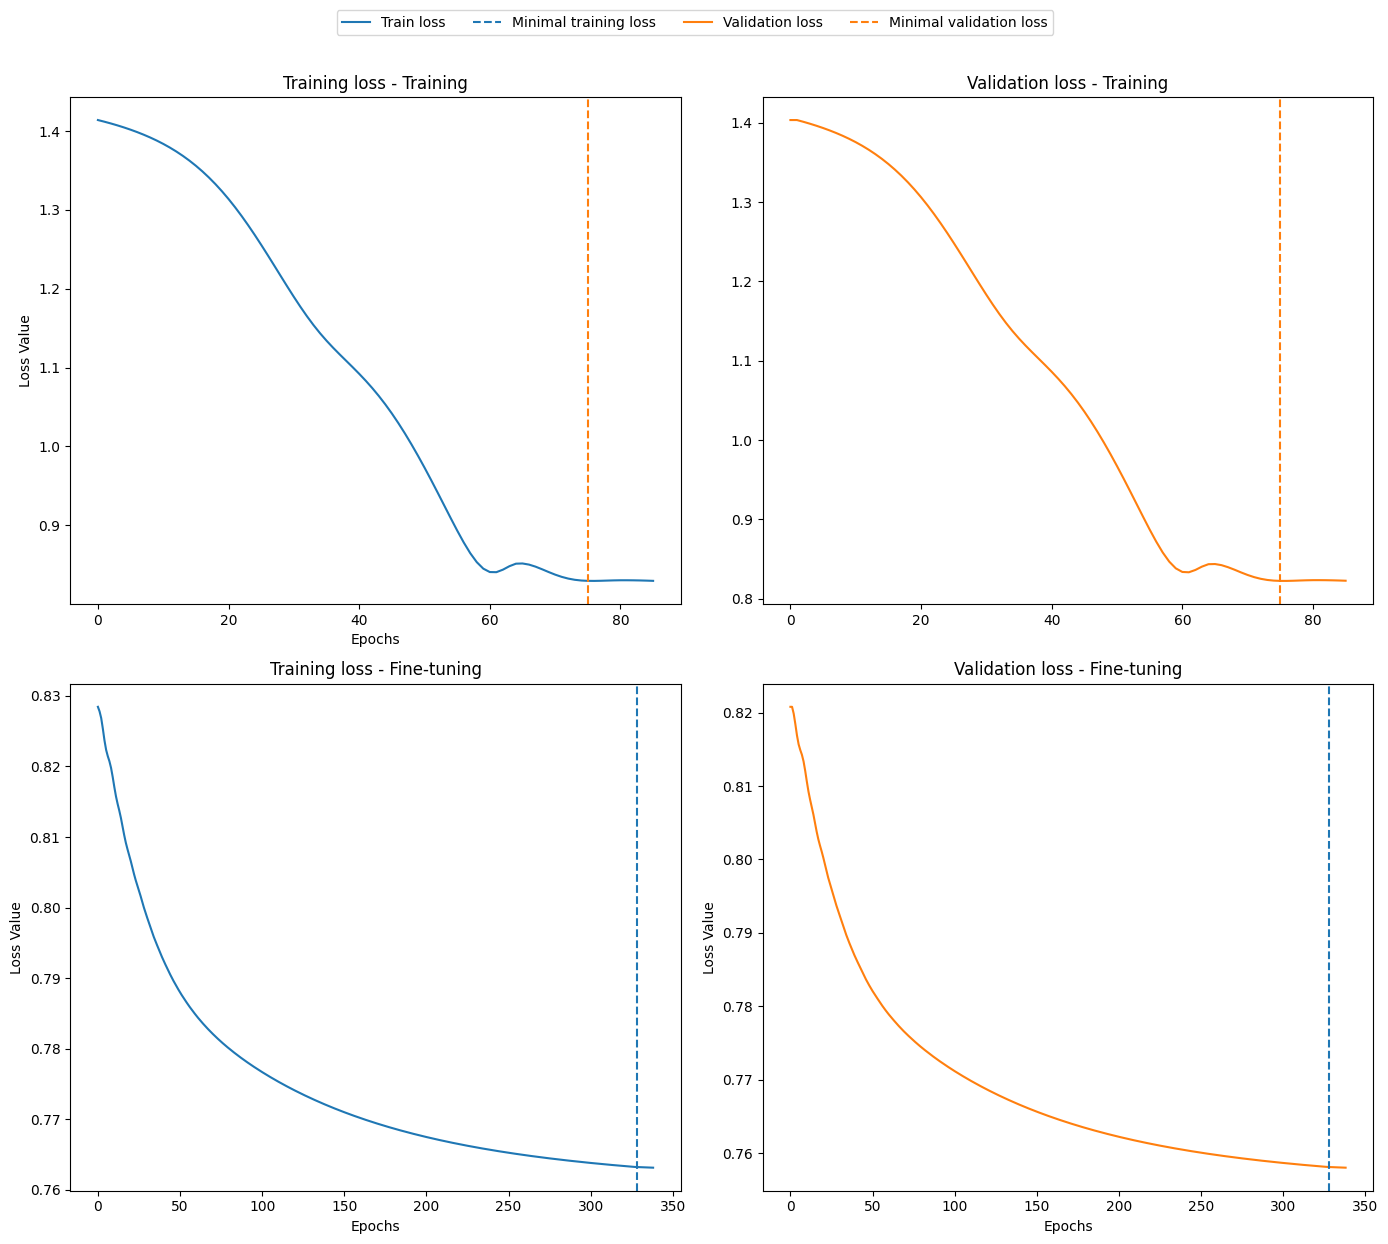

In [110]:
utils.plot_model_convergence( loglogistic_model )

In [134]:
def get_survival_loglogistic(model, y_train, z_train, X_train, y_test, z_test, X_test, ngrid = 100):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    a_train = pred_train["scale"].numpy().flatten()
    b_train = pred_train["shape"].numpy().flatten()
    a_test = pred_test["scale"].numpy().flatten()
    b_test = pred_test["shape"].numpy().flatten()
    beta = model.predict("beta")[:,None]

    log_a_train = np.log(a_train)
    log_a_test = np.log(a_test)

    ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), ngrid)[:,None]
    
    r_z_train = np.dot(z_train, beta).flatten()
    t0_grid_train = ts_grid * np.exp( -r_z_train )
    log_t0_grid_train = np.log( t0_grid_train )
    
    terms_train_t0 = tf.math.softplus( b_train*( log_t0_grid_train - log_a_train ) ).numpy()
    S_ts_train = np.exp( -terms_train_t0 )
    t0_train = y_train * np.exp( -r_z_train )
    log_t0_train = np.log( t0_train )
    terms_train = tf.math.softplus( b_train*( log_t0_train - log_a_train ) ).numpy()
    S_train = np.exp( -terms_train )
    H_train = -np.log( S_train )

    r_z_test = np.dot(z_test, beta).flatten()
    t0_grid_test = ts_grid * np.exp( -r_z_test )
    log_t0_grid_test = np.log( t0_grid_test )
    
    terms_test_t0 = tf.math.softplus( b_test*( log_t0_grid_test - log_a_test ) ).numpy()
    S_ts_test = np.exp( -terms_test_t0 )
    t0_test = y_test * np.exp( -r_z_test )
    log_t0_test = np.log(t0_test)
    terms_test = tf.math.softplus( b_test*( log_t0_test - log_a_test ) ).numpy()
    S_test = np.exp( -terms_test )
    H_test = -np.log( S_test )
    
    return {
        "ts_grid": ts_grid,
        "S_ts_train": S_ts_train,
        "S_ts_test": S_ts_test,
        "S_train": S_train,
        "S_test": S_test,
        "H_train": H_train,
        "H_test": H_test
    }

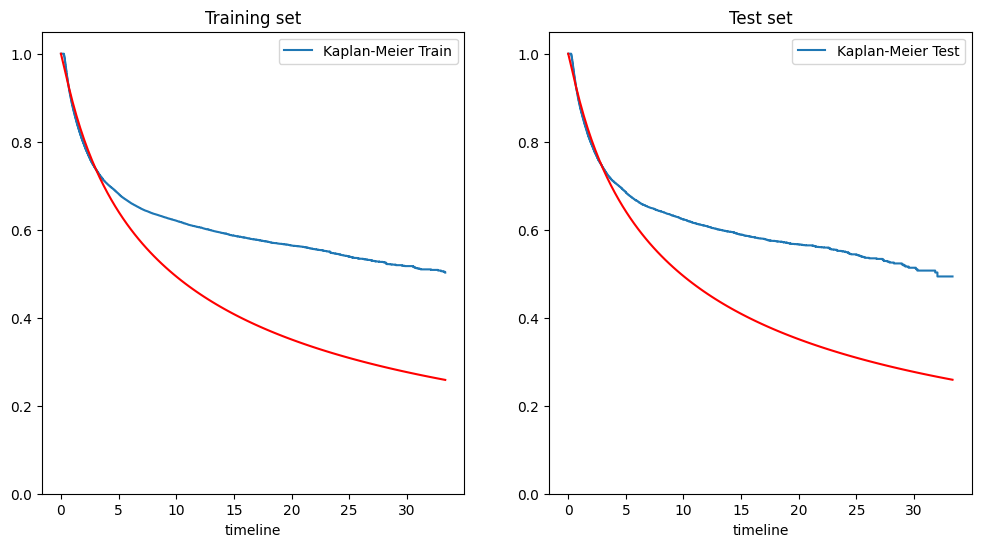

In [137]:
results_loglogistic = get_survival_loglogistic(loglogistic_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_loglogistic["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_loglogistic["S_ts_train"].shape[1]), size = np.min([n_max, results_loglogistic["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_loglogistic["S_ts_test"].shape[1]), size = np.min([n_max, results_loglogistic["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_loglogistic["ts_grid"].flatten(),
                           results_loglogistic["S_ts_train"][:, train_idx], results_loglogistic["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [141]:
beta_summary = loglogistic_model.summary()

beta_hats = []
beta_ses = []
beta_statistics = []
beta_pvalues = []
beta_CIs = []
for j, beta in enumerate(beta_summary.columns[1::4]):
    beta_hat = float( beta_summary.iloc[0,j*4+1] )
    se = float( beta_summary.iloc[0,j*4+2] )

    test_statistic = beta_hat / se
    p_value = 2.0 * (1.0 - norm.cdf(np.abs(test_statistic)))
    
    lower = float( beta_summary.iloc[0,j*4+3] )
    upper = float( beta_summary.iloc[0,j*4+4] )

    beta_hats.append( beta_hat )
    beta_ses.append( se )
    beta_statistics.append( test_statistic )
    beta_pvalues.append( p_value )
    beta_CIs.append("({} ; {})".format(np.round(lower,4), np.round(upper,4)))
beta_summary = pd.DataFrame({"Coef": beta_hats, "Se": beta_ses, "Z": beta_statistics, "pvalue": beta_pvalues, "CI(95%)": beta_CIs})
beta_summary.index = z_train.columns
beta_summary

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2719: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,0.532812,0.005560,95.829556,0.000000,(0.5219 ; 0.5437)
sexo_feminino,0.134809,0.010795,12.488193,0.000000,(0.1137 ; 0.156)
raca_amarela,-0.000875,0.049160,-0.017801,0.985798,(-0.0972 ; 0.0955)
raca_indigena,0.045718,0.100024,0.457066,0.647624,(-0.1503 ; 0.2418)
raca_parda,0.136131,0.011569,11.767089,0.000000,(0.1135 ; 0.1588)
raca_preta,0.077021,0.019801,3.889725,0.000100,(0.0382 ; 0.1158)
faixa_remuneracao_media_2 a 4 SM,0.586552,0.016402,35.761171,0.000000,(0.5544 ; 0.6187)
faixa_remuneracao_media_4 a 7 SM,0.777155,0.028510,27.259494,0.000000,(0.7213 ; 0.833)
faixa_remuneracao_media_até 1 SM,-0.951263,0.012474,-76.258772,0.000000,(-0.9757 ; -0.9268)
faixa_remuneracao_media_mais de 7 SM,0.971792,0.033747,28.796501,0.000000,(0.9056 ; 1.0379)


### Birnbaun-Saunders model

In [138]:
with tf.device("/GPU:0"):
    seed = 10
    bs_model = thf.ModelNN(bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast,
                           input_dim = (X_train_nn.shape[1],), seed = seed)
    bs_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    bs_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                         shuffle = True,
                         get_covariances = True,
                         validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                         force_training_validation = False,
                         optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                         optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                         fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                         early_stopping = True, early_stopping_patience = 10, 
                         early_stopping_warmup = 50,
                         reduce_lr = True, reduce_lr_warmup = 0,
                         reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                         fine_tune = True,
                         finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                         finetune_early_stopping_warmup = 50,
                         finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                         finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                         finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                         deterministic = True,
                         verbose = True, print_freq = 1,
                         train_batch_size = None, val_batch_size = None,
                         buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 74 / 5000 ]  | Loss:  0.793582618 | Best Loss:  0.786436796 | Speed:  25  epoch/s    | Elapsed Time:  2.92440724  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 390 / 5000 ]  | Loss:  0.758642 | Best Loss:  0.758740306 | Speed:  41  epoch/s    | Elapsed Time:  9.4012394  s   s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 17.082 seconds.


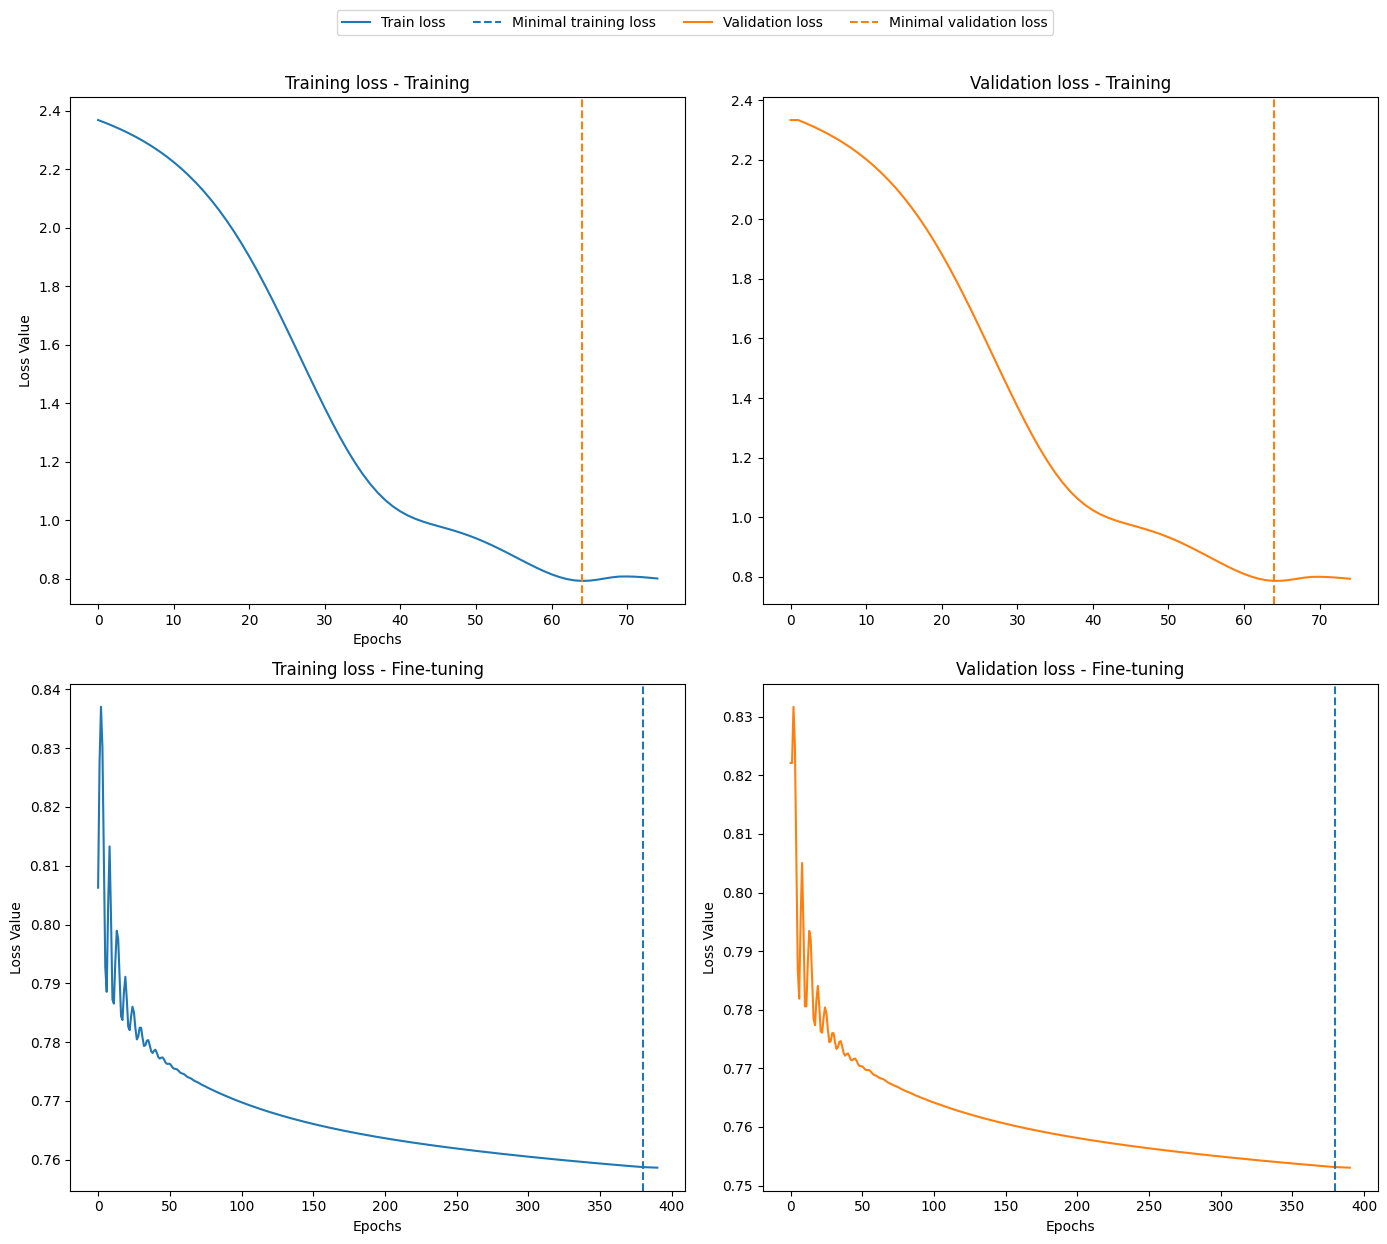

In [139]:
utils.plot_model_convergence( bs_model )

In [154]:
def get_survival_bs(model, y_train, z_train, X_train, y_test, z_test, X_test, ngrid = 100):
    eps = tf.constant(1.0e-7, dtype = tf.float32)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    a_train = pred_train["shape"].numpy().flatten()
    b_train = pred_train["scale"].numpy().flatten()
    a_test = pred_test["shape"].numpy().flatten()
    b_test = pred_test["scale"].numpy().flatten()
    beta = model.predict("beta")[:,None]

    pi = tf.constant( 3.141592653589793, dtype = tf.float32 )
    log_a_train = np.log(a_train)
    log_a_test = np.log(a_test)
    log_b_train = np.log(b_train)
    log_b_test = np.log(b_test)

    normal_dist = tfp.distributions.Normal(loc = 0.0, scale = 1.0)
    
    ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), ngrid)[:,None]
    
    r_z_train = np.dot(z_train, beta).flatten()
    t0_grid_train = ts_grid * np.exp( -r_z_train )
    
    sqrt_b_t0_grid_train = tf.math.sqrt( b_train / (t0_grid_train+eps) )
    sqrt_t0_grid_b_train = tf.math.sqrt( t0_grid_train / b_train )
    zs_score_train = (sqrt_t0_grid_b_train - sqrt_b_t0_grid_train) / a_train
    S_ts_train = normal_dist.survival_function(zs_score_train).numpy()

    t0_train = y_train * np.exp( -r_z_train )
    
    sqrt_b_t0_train = tf.math.sqrt( b_train / (t0_train+eps) )
    sqrt_t0_b_train = tf.math.sqrt( t0_train / b_train )
    z_score_train = (sqrt_t0_b_train - sqrt_b_t0_train) / a_train
    S_train = normal_dist.survival_function(z_score_train).numpy()
    H_train = -np.log( S_train )

    r_z_test = np.dot(z_test, beta).flatten()
    t0_grid_test = ts_grid * np.exp( -r_z_test )
    
    sqrt_b_t0_grid_test = tf.math.sqrt( b_test / (t0_grid_test+eps) )
    sqrt_t0_grid_b_test = tf.math.sqrt( t0_grid_test / b_test )
    zs_score_test = (sqrt_t0_grid_b_test - sqrt_b_t0_grid_test) / a_test
    S_ts_test = normal_dist.survival_function(zs_score_test).numpy()

    t0_test = y_test * np.exp( -r_z_test )
    
    sqrt_b_t0_test = tf.math.sqrt( b_test / (t0_test+eps) )
    sqrt_t0_b_test = tf.math.sqrt( t0_test / b_test )
    z_score_test = (sqrt_t0_b_test - sqrt_b_t0_test) / a_test
    S_test = normal_dist.survival_function(z_score_test).numpy()
    H_test = -np.log( S_test )
    
    return {
        "ts_grid": ts_grid,
        "S_ts_train": S_ts_train,
        "S_ts_test": S_ts_test,
        "S_train": S_train,
        "S_test": S_test,
        "H_train": H_train,
        "H_test": H_test
    }

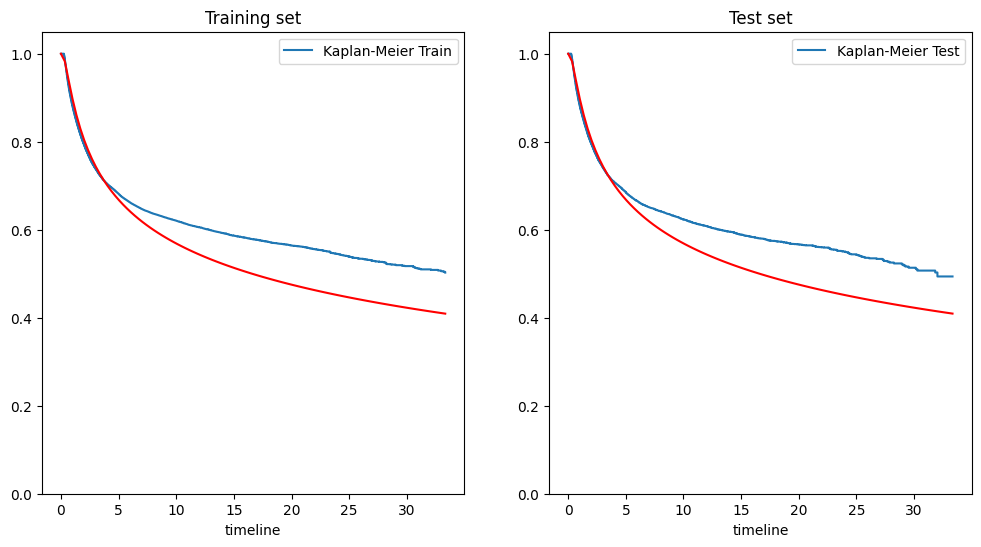

In [155]:
results_bs = get_survival_bs(bs_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_bs["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_bs["S_ts_train"].shape[1]), size = np.min([n_max, results_bs["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_bs["S_ts_test"].shape[1]), size = np.min([n_max, results_bs["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_bs["ts_grid"].flatten(),
                           results_bs["S_ts_train"][:, train_idx], results_bs["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [156]:
beta_summary = bs_model.summary()

beta_hats = []
beta_ses = []
beta_statistics = []
beta_pvalues = []
beta_CIs = []
for j, beta in enumerate(beta_summary.columns[1::4]):
    beta_hat = float( beta_summary.iloc[0,j*4+1] )
    se = float( beta_summary.iloc[0,j*4+2] )

    test_statistic = beta_hat / se
    p_value = 2.0 * (1.0 - norm.cdf(np.abs(test_statistic)))
    
    lower = float( beta_summary.iloc[0,j*4+3] )
    upper = float( beta_summary.iloc[0,j*4+4] )

    beta_hats.append( beta_hat )
    beta_ses.append( se )
    beta_statistics.append( test_statistic )
    beta_pvalues.append( p_value )
    beta_CIs.append("({} ; {})".format(np.round(lower,4), np.round(upper,4)))
beta_summary = pd.DataFrame({"Coef": beta_hats, "Se": beta_ses, "Z": beta_statistics, "pvalue": beta_pvalues, "CI(95%)": beta_CIs})
beta_summary.index = z_train.columns
beta_summary

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2719: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,0.260204,0.004590,56.686772,0.000000,(0.2512 ; 0.2692)
sexo_feminino,0.107173,0.009958,10.762548,0.000000,(0.0877 ; 0.1267)
raca_amarela,-0.004773,0.043501,-0.109713,0.912637,(-0.09 ; 0.0805)
raca_indigena,-0.054513,0.090302,-0.603673,0.546061,(-0.2315 ; 0.1225)
raca_parda,0.045475,0.010426,4.361558,0.000013,(0.025 ; 0.0659)
raca_preta,0.010239,0.017726,0.577642,0.563506,(-0.0245 ; 0.045)
faixa_remuneracao_media_2 a 4 SM,0.275947,0.013830,19.952273,0.000000,(0.2488 ; 0.3031)
faixa_remuneracao_media_4 a 7 SM,0.362557,0.024345,14.892222,0.000000,(0.3148 ; 0.4103)
faixa_remuneracao_media_até 1 SM,-0.668094,0.012213,-54.704774,0.000000,(-0.692 ; -0.6442)
faixa_remuneracao_media_mais de 7 SM,0.424349,0.031671,13.398699,0.000000,(0.3623 ; 0.4864)
